## WorldView-2 Jitter at Atlanta: Does Solving for It Change the Benchmark?

The [Atlanta full-strip benchmark](https://asp-plot.readthedocs.io/en/latest/examples/notebooks/worldview_spacenet_atlanta_full_benchmark.html) scored 21 DEMs from five same-pass WorldView-2 strips (2009-12-22), each about 27 km north–south. Linescan cameras record small, fast attitude oscillations, "jitter", that the delivered camera models do not fully capture. Long strips over flat terrain are where jitter should show, as along-track ripples in the DEMs. ASP's [`jitter_solve`](https://stereopipeline.readthedocs.io/en/latest/tools/jitter_solve.html) estimates them from many image matches and corrects the cameras.

Questions:
1. Is there measurable jitter in these strips?
2. Does solving for it improve the DEMs, and by how much for narrow vs. wide pairs?
3. Does it change the benchmark's conclusions? In particular, do the DEMs become *less separable* once a shared error source is removed?

**Recipe.** This follows the ASP docs' WorldView-3 example ("Example 2"):
- 400 image lines per position and per orientation sample;
- camera position uncertainty 1000 m;
- 10,000 anchor points per image on Copernicus GLO-30 (COP30) at 50 m;
- `--tri-weight 0.1`;
- dense matches from stereo disparity (`--num-matches-from-disparity 60000` per pair).

The input cameras are the benchmark's shared five-scene bundle adjustment. The docs' optional camera-alignment step was skipped, because those cameras are already within about 1 m of ICESat-2.

**Selective re-processing.** No correlation was redone. Each archived pair was **re-triangulated from its disparity** (`parallel_stereo --prev-run-prefix`, the docs' "Reusing a previous run"), first with the original cameras as a control, then with the jitter-solved ones. That costs about 1.5 node-hours per pair instead of about 18. "Tier 1" is six DEMs across the convergence range: mapprojected 13-16 (4.5°), 13-21 (9.9°), 13-8 (17.0°), 13-10 (21.8°) and 10-21 (31.7°), and the best DEM, raw 10-21.

**Geometry caveat.** All five strips come from one pass. Their across-track angles are all −6° to −8°, so the scan lines are nearly parallel. The docs name this as the case where jitter "cannot be fully disambiguated". Differences in jitter between images are observable, but jitter common to all of them is held only by the anchor points.

**Scoring.**
- ICESat-2 ATL06-SR on stable terrain (water and trees removed), as in the benchmark.
- 3DEP lidar (`GA_Statewide_2018`, flown 2018–2019) on open ground, as in the [lidar comparison](https://asp-plot.readthedocs.io/en/latest/examples/notebooks/worldview_spacenet_lidar_comparison.html).
- Before/after differences use the paired block bootstrap: ICESat-2 beam tracks, or 1 km lidar blocks.

In [1]:
import glob, os, contextlib, io
import numpy as np, pandas as pd, rasterio as rio
import matplotlib.pyplot as plt
from rasterio.enums import Resampling
from asp_plot.dem_benchmark import DEMBenchmark, paired_block_bootstrap

FB = "/nobackup/bpurint1/data/atlanta/WV/20091222_spacenet/full_benchmark"
J = f"{FB}/jitter"
LID = "/nobackup/bpurint1/data/atlanta/lidar"
CID = {"8": "10300100023BC100", "10": "1030010003CAF100", "13": "1030010002B7D800",
       "16": "1030010002649200", "21": "1030010003127500"}
TIER1 = [("13-16", "map", "13_16", 4.5), ("13-21", "map", "13_21", 9.9), ("13-8", "map", "13_8", 17.0),
         ("13-10", "map", "13_10", 21.8), ("10-21", "map", "10_21", 31.7), ("raw_10-21", "raw", "10_21", 31.7)]
VARIANTS = {"original": "original cameras", "nohfd": "joint solve v1 (docs settings)",
            "lidar": "joint solve v1, lidar-constrained", "v2": "joint solve v2 (rigid positions)"}

### 1. Is there jitter? Evidence before any solving

Two independent views of the original DEMs:
- **Triangulation error** (`point2dem --errorimage`), the miss distance between the two rays of each pixel. Jitter in either image moves its rays, so it shows as along-track waves.
- **DEM − lidar on open ground**, in 250 m bins of northing (the strips run north–south). This shows the height ripples directly.

along-track ripple: std of 250 m bin medians after removing a 2.25 km running median (m)
label
MVS_5_ref_nadir10         0.090
pair_10-21_31.7           0.093
raw_pair_10-21_31.7       0.100
MVS_5_ref_nadir13         0.101
10_pairs_median_mosaic    0.101
6_pairs_15_mosaic         0.103
pair_13-10_21.8           0.104
pair_10-16_26.3           0.108
raw_pair_13-10_21.8       0.109
pair_8-21_27.0            0.117
raw_pair_8-21_27.0        0.134
pair_8-16_21.6            0.136
pair_13-8_17.0            0.150
10_pairs_mosaic           0.179
pair_13-21_9.9            0.219
raw_pair_8-10_4.8         0.435
raw_pair_13-16_4.5        0.442
pair_16-21_5.4            0.443
pair_13-16_4.5            0.450
pair_8-10_4.8             0.491
raw_pair_16-21_5.4        0.499


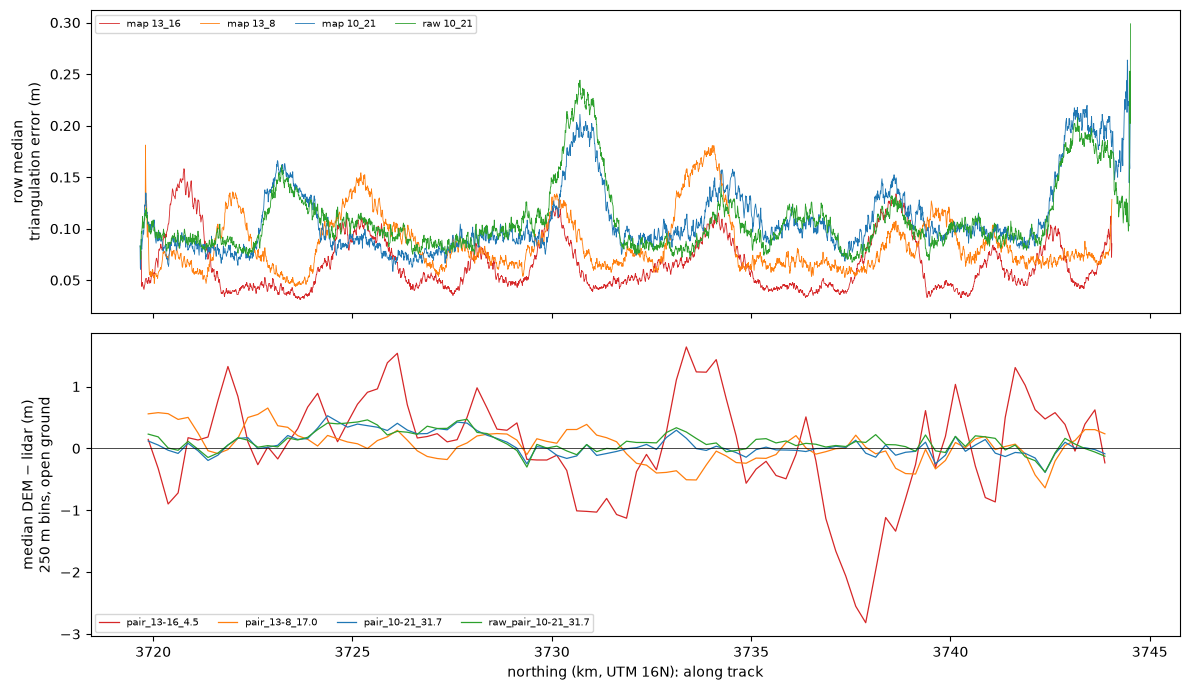

In [2]:
fig, axs = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for run, c in [("map/stereo_pair_13_16", "C3"), ("map/stereo_pair_13_8", "C1"), ("map/stereo_pair_10_21", "C0"),
               ("raw/stereo_pair_10_21", "C2")]:
    with rio.open(f"{FB}/{run}/run-IntersectionErr.tif") as ds:
        f = 4
        a = ds.read(1, out_shape=(ds.height // f, ds.width // f), resampling=Resampling.nearest, masked=True).filled(np.nan)
        y = ds.bounds.top - (np.arange(a.shape[0]) + 0.5) * ds.res[1] * f
    axs[0].plot(y / 1e3, np.nanmedian(a, axis=1), lw=0.6, c=c, label=run.replace("stereo_pair_", "").replace("/", " "))
axs[0].set_ylabel("row median\ntriangulation error (m)"); axs[0].legend(fontsize=7, ncol=4)
al = pd.read_csv(f"{LID}/compare/along_track.csv")
for lab, c in [("pair_13-16_4.5", "C3"), ("pair_13-8_17.0", "C1"), ("pair_10-21_31.7", "C0"), ("raw_pair_10-21_31.7", "C2")]:
    g = al[(al.label == lab) & (al.n > 2000)]
    axs[1].plot(g.northing / 1e3, g["median"], lw=0.9, c=c, label=lab)
axs[1].axhline(0, c="k", lw=0.5); axs[1].set_ylabel("median DEM − lidar (m)\n250 m bins, open ground")
axs[1].set_xlabel("northing (km, UTM 16N): along track"); axs[1].legend(fontsize=7, ncol=4)
plt.tight_layout()

w = al[al.n > 2000].pivot(index="northing", columns="label", values="median")
ripple = (w - w.rolling(9, center=True, min_periods=3).median()).std()
print("along-track ripple: std of 250 m bin medians after removing a 2.25 km running median (m)")
print(ripple.sort_values().round(3).to_string())

The triangulation error has quasi-periodic waves with a period of 2–3 km on the ground, about 4,000–6,000 image lines (0.2–0.3 s at WorldView-2's 20,000 lines per second).
- Map and raw 10-21 trace the same curve, so the waves come from the cameras, not from stereo processing.
- 13-8 and 13-16 are out of phase with each other, as a per-image attitude oscillation predicts.

In height, the ripple grows as the base shrinks: about 0.1 m for wide pairs, 0.15 m at 17°, and 0.44–0.50 m for the 4.5–5.4° pairs. That is the 1/(base-to-height) amplification expected of an angular error.

### 2. What the solver does

Reprojection residuals of the dense matches before and after solving, in about 100 m latitude bins. The first row is the two-image solve of 13 + 8 with no ground constraint, the second the joint five-scene solve. The table lists, per solve and image, the mean pixel residual before and after, and how far the triangulated points moved.

matches  mean px before  mean px after  \
solve                 scene                                           
pair 13+8             13       66889           0.128          0.112   
                      8        66889           0.131          0.104   
pair 13+8, COP30 10 m 13       66889           0.992          0.110   
                      8        66889           1.033          0.104   
joint                 13      164117           0.182          0.198   
                      10       97927           0.464          0.205   
                      8        66888           0.240          0.179   
                      16       66746           0.196          0.141   
                      21       97426           0.301          0.202   
joint, COP30 10 m     13      164117           0.643          0.191   
                      10       97927           1.945          0.201   
                      8        66888           1.297          0.184   
                      16       66746           0.751          0.139   
                      21       97426           1.462          0.216   
joint, lidar 1 m      13      164117           0.216          0.211   
                      10       97927           0.553          0.216   
                      8        66888           0.301          0.193   
                      16       66746           0.235          0.150   
                      21       97426           0.381          0.219   
joint v2              13      164117           0.182          0.198   
                      10       97927           0.464          0.205   
                      8        66888           0.240          0.179   
                      16       66746           0.196          0.142   
                      21       97426           0.301          0.203   

                             point shift median (m)  \
solve                 scene                           
pair 13+8             13                      0.024   
                      8                       0.024   
pair 13+8, COP30 10 m 13                      1.676   
                      8                       1.676   
joint                 13                      0.141   
                      10                      0.162   
                      8                       0.161   
                      16                      0.129   
                      21                      0.172   
joint, COP30 10 m     13                      2.015   
                      10                      1.983   
                      8                       1.881   
                      16                      2.201   
                      21                      1.992   
joint, lidar 1 m      13                      0.152   
                      10                      0.170   
                      8                       0.165   
                      16                      0.145   
                      21                      0.180   
joint v2              13                      0.141   
                      10                      0.163   
                      8                       0.161   
                      16                      0.128   
                      21                      0.173   

                             camera centre moved, horiz. (m)  vert. (m)  
solve                 scene                                              
pair 13+8             13                            8711.669   1545.024  
                      8                              314.000    772.111  
pair 13+8, COP30 10 m 13                            1443.946   5026.434  
                      8                              722.922    801.649  
joint                 13                             394.272   4610.517  
                      10                           16940.363   5571.869  
                      8                              392.719    464.542  
                      16                            1622.020   2229.436  
           

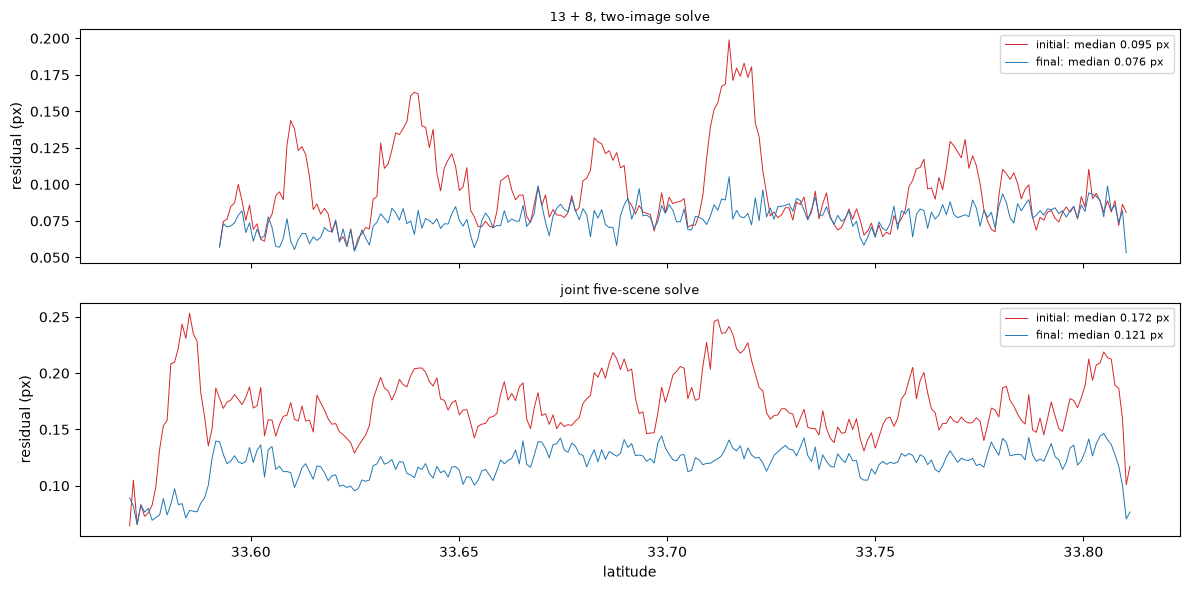

In [3]:
def pointmap(d, stage):
    return pd.read_csv(f"{J}/{d}/run-{stage}_residuals_pointmap.csv", comment="#", header=None,
                       names=["lon", "lat", "h", "r", "n"])

fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
for ax, d, title in [(axs[0], "solve_13_8_nohfd", "13 + 8, two-image solve"),
                     (axs[1], "solve_all_nohfd", "joint five-scene solve")]:
    for stage, c in (("initial", "C3"), ("final", "C0")):
        p = pointmap(d, stage)
        g = p.groupby((p.lat / 0.0009).round() * 0.0009).r.median()
        ax.plot(g.index, g.values, c, lw=0.7, label=f"{stage}: median {p.r.median():.3f} px")
    ax.set_title(title, fontsize=9); ax.set_ylabel("residual (px)"); ax.legend(fontsize=8)
axs[1].set_xlabel("latitude"); plt.tight_layout()

def stats_file(d, kind):
    return pd.read_csv(f"{J}/{d}/run-{kind}.txt", comment="#", header=None, sep=r"[,\s]+", engine="python",
                       names=["image", "mean", "median", "count"])
rows = []
for d, name in [("solve_13_8_nohfd", "pair 13+8"), ("solve_13_8_hfd", "pair 13+8, COP30 10 m"),
                ("solve_all_nohfd", "joint"), ("solve_all_hfd", "joint, COP30 10 m"),
                ("solve_all_lidar", "joint, lidar 1 m"), ("solve_all_v2", "joint v2")]:
    a, b, t = (stats_file(d, k) for k in ("initial_residuals_stats", "final_residuals_stats", "triangulation_offsets"))
    for i in range(len(a)):
        sc = {v: k for k, v in CID.items()}[a.image[i].replace(".tif", "")]
        off = pd.read_csv(f"{J}/{d}/run-camera_offsets.txt", comment="#", header=None, sep=r"\s+",
                          names=["image", "h", "v"])
        rows.append({"solve": name, "scene": sc, "matches": int(a["count"][i]), "mean px before": a["mean"][i],
                     "mean px after": b["mean"][i], "point shift median (m)": t["median"][i],
                     "camera centre moved, horiz. (m)": off.h[i], "vert. (m)": off.v[i]})
pd.DataFrame(rows).set_index(["solve", "scene"]).round(3)

Without a ground constraint, the solver removes the along-track peaks of the residuals. With COP30 as a 10 m height constraint, the starting residuals are dominated by the misfit to COP30, and the solve moves every triangulated point by about 2 m. COP30 is a 30 m X-band surface model that sits on the canopy in wooded Atlanta, so it pulls the cameras off. The lidar constraint (open ground only, 1 m) moves points by about 0.15 m, as much as the unconstrained joint solve does.

### 3. Pair-solve smoke test on 13-8

The first test used 13-8 alone, with the re-triangulation control. The control re-triangulates the archived disparity with the *original* cameras and must reproduce the benchmark DEM.

In [4]:
sm = pd.read_csv(f"{J}/bench_smoke_13_8/dem_benchmark.csv").set_index("label")
sl = pd.read_csv(f"{LID}/compare_jitter_smoke_13_8/stats.csv").set_index("label")
pd.DataFrame({"ICESat-2 NMAD (m)": sm.dh_aligned_shared_nmad_m, "lidar NMAD (m)": sl.shared_nmad}).round(3)

,ICESat-2 NMAD (m),lidar NMAD (m)
label,,
13-8_original,1.054,0.885
13-8_retri_ba,1.054,0.885
13-8_jitter_nohfd,1.059,0.889
13-8_jitter_hfd,1.914,1.667


The control matches the original to the last digit, so re-triangulating from the archived disparity is a clean before/after test. The two-image solve changes nothing measurable; with COP30 it badly damages the DEM. A pair alone cannot see the part of the jitter that moves points along the epipolar direction, because that part becomes height. In the joint solve, scene 13 appears in four pairs and scene 10 in two, which ties the solutions together.

### 4. Tier 1: six DEMs before and after the joint solves

All 18 DEMs (6 × original, joint, joint lidar-constrained) are scored on the same shared ICESat-2 points and the same shared open-ground lidar cells. **Δ** is the after − before difference in NMAD, with its paired bootstrap 95 % interval; negative is better. For the lidar-constrained solve, the lidar columns are *not independent*: that solve was fitted to the same lidar. Judge it by ICESat-2.

In [5]:
specs = {}
for name, mode, p, conv in TIER1:
    orig = f"{FB}/{mode}/stereo_pair_{p}/run-DEM.tif"
    specs[f"{name}_original"] = orig
    for v in ("nohfd", "lidar"):
        specs[f"{name}_{v}"] = f"{J}/retri_solve_all_{v}/{mode}/stereo_pair_{p}/run-DEM.tif"
bench = DEMBenchmark(f"{J}/bench_tier1", specs, parquet=f"{FB}/atl06sr_all.parquet",
                     filter_out=["water", "trees"], n_bootstrap=1000)
with contextlib.redirect_stdout(io.StringIO()):
    bench.run(pc_align=True)
ids = bench.shared_ids
is2 = np.vstack([bench.dh_aligned[l].reindex(ids).values for l in specs])
is2_blocks = pd.Series(bench.blocks).reindex(ids).values
lat = np.load(f"{LID}/compare_jitter_tier1/lattice.npz")
lab_idx = {l: i for i, l in enumerate(lat["labels"])}
lid = np.vstack([lat["dh"][lab_idx[l]] for l in specs])
labels = list(specs)
bs_is2 = paired_block_bootstrap(is2, blocks=is2_blocks, n_boot=1000, seed=0)
bs_lid = paired_block_bootstrap(lid, blocks=lat["blocks"], n_boot=1000, seed=0)
print(f"{len(ids):,} shared ICESat-2 points on {bs_is2['n_blocks']} beam tracks; "
      f"{lid.shape[1]:,} lidar lattice cells (20 m) in {bs_lid['n_blocks']} 1 km blocks")

def nmad(v):
    v = v[np.isfinite(v)]; return 1.4826 * np.median(np.abs(v - np.median(v)))

rows = []
for name, mode, p, conv in TIER1:
    i0 = labels.index(f"{name}_original")
    r = {"DEM": name.replace("_", " "), "conv (°)": conv,
         "ICESat-2 before": nmad(is2[i0]), "lidar before": nmad(lid[i0])}
    for v in ("nohfd", "lidar"):
        i = labels.index(f"{name}_{v}")
        for ref, M, bs in (("ICESat-2", is2, bs_is2), ("lidar", lid, bs_lid)):
            d = bs["nmad"][:, i] - bs["nmad"][:, i0]
            lo, hi = np.percentile(d, [2.5, 97.5])
            r[f"{ref} Δ {v}"] = f"{nmad(M[i]) - nmad(M[i0]):+.3f} [{lo:+.3f}, {hi:+.3f}]"
    rows.append(r)
tier1 = pd.DataFrame(rows).set_index("DEM")
tier1.round(3)

39,087 shared ICESat-2 points on 173 beam tracks; 90,267 lidar lattice cells (20 m) in 439 1 km blocks


,conv (°),ICESat-2 before,lidar before,ICESat-2 Δ nohfd,lidar Δ nohfd,ICESat-2 Δ lidar,lidar Δ lidar
DEM,,,,,,,
13-16,4.5,1.601,1.519,"-0.189 [-0.211, -0.167]","-0.182 [-0.220, -0.149]","-0.210 [-0.234, -0.187]","-0.216 [-0.259, -0.177]"
13-21,9.9,1.201,1.098,"-0.146 [-0.164, -0.128]","-0.159 [-0.187, -0.132]","-0.158 [-0.176, -0.141]","-0.179 [-0.206, -0.150]"
13-8,17.0,0.956,0.825,"-0.034 [-0.044, -0.022]","-0.044 [-0.064, -0.023]","-0.019 [-0.031, -0.006]","-0.030 [-0.049, -0.010]"
13-10,21.8,0.892,0.750,"-0.007 [-0.017, +0.005]","+0.002 [-0.012, +0.015]","-0.018 [-0.027, -0.007]","-0.016 [-0.029, -0.003]"
10-21,31.7,0.905,0.767,"-0.005 [-0.012, +0.005]","+0.000 [-0.006, +0.006]","-0.016 [-0.021, -0.009]","-0.017 [-0.022, -0.011]"
raw 10-21,31.7,0.757,0.608,"-0.010 [-0.015, -0.003]","-0.011 [-0.018, -0.007]","-0.003 [-0.008, +0.005]","-0.000 [-0.006, +0.006]"


### 5. Does the spread between DEMs change?

The benchmark's separability question, restricted to the six tier-1 DEMs: NMAD against convergence before and after, and the spread (worst − best).

,,best − worst (m),spread of the >15° DEMs (m),DEMs separable from the best (of 5)
reference,cameras,,,
ICESat-2,original cameras,0.844,0.199,5
lidar,original cameras,0.912,0.217,5
ICESat-2,joint solve v1 (docs settings),0.665,0.175,5
lidar,joint solve v1 (docs settings),0.741,0.184,5
ICESat-2,"joint solve v1, lidar-constrained",0.637,0.183,5
lidar,"joint solve v1, lidar-constrained",0.695,0.188,5


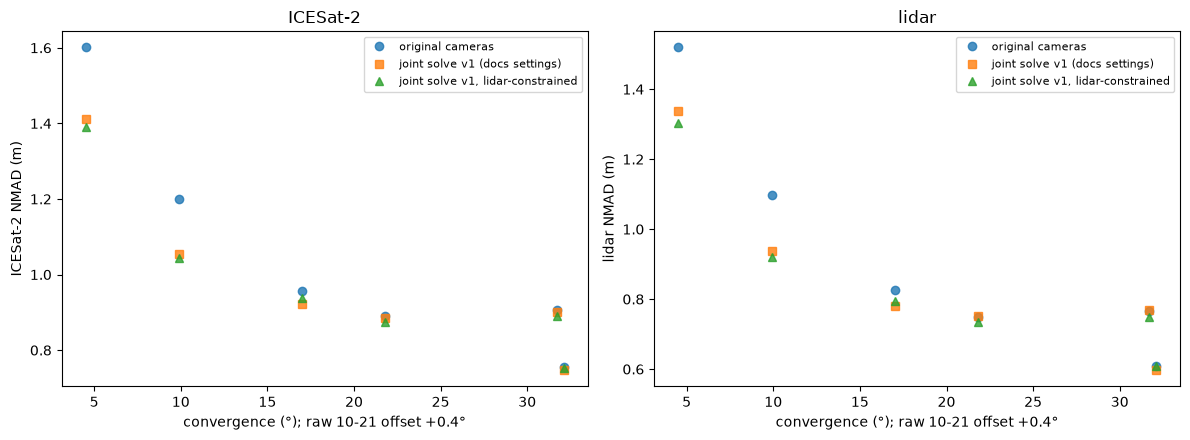

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (ref, M) in zip(axs, (("ICESat-2", is2), ("lidar", lid))):
    for v, mk in (("original", "o"), ("nohfd", "s"), ("lidar", "^")):
        xs, ys = [], []
        for name, mode, p, conv in TIER1:
            xs.append(conv + (0.4 if mode == "raw" else 0)); ys.append(nmad(M[labels.index(f"{name}_{v}")]))
        ax.plot(xs, ys, mk, label=VARIANTS[v], ms=6, alpha=0.8)
    ax.set_xlabel("convergence (°); raw 10-21 offset +0.4°"); ax.set_ylabel(f"{ref} NMAD (m)"); ax.set_title(ref)
    ax.legend(fontsize=8)
plt.tight_layout()

spread = []
for v in ("original", "nohfd", "lidar"):
    for ref, M, bs in (("ICESat-2", is2, bs_is2), ("lidar", lid, bs_lid)):
        idx = [labels.index(f"{n}_{v}") for n, *_ in TIER1]
        vals = [nmad(M[i]) for i in idx]
        sub = bs["nmad"][:, idx]
        best = int(np.argmin(vals))
        d = sub - sub[:, [best]]
        sep = int(sum(np.percentile(d[:, k], 2.5) > 0 for k in range(len(idx)) if k != best))
        wide = [nmad(M[labels.index(f"{n}_{v}")]) for n, m, p, c in TIER1 if c > 15]
        spread.append({"cameras": VARIANTS[v], "reference": ref, "best − worst (m)": max(vals) - min(vals),
                       "spread of the >15° DEMs (m)": max(wide) - min(wide),
                       "DEMs separable from the best (of 5)": sep})
pd.DataFrame(spread).set_index(["reference", "cameras"]).round(3)

### 6. Along-track ripple before and after

,original cameras,joint solve v1 (docs settings),"joint solve v1, lidar-constrained"
13-16,0.448,0.304,0.317
13-21,0.222,0.142,0.129
13-8,0.151,0.120,0.297
13-10,0.106,0.105,0.096
10-21,0.096,0.100,0.089
raw 10-21,0.105,0.099,0.098


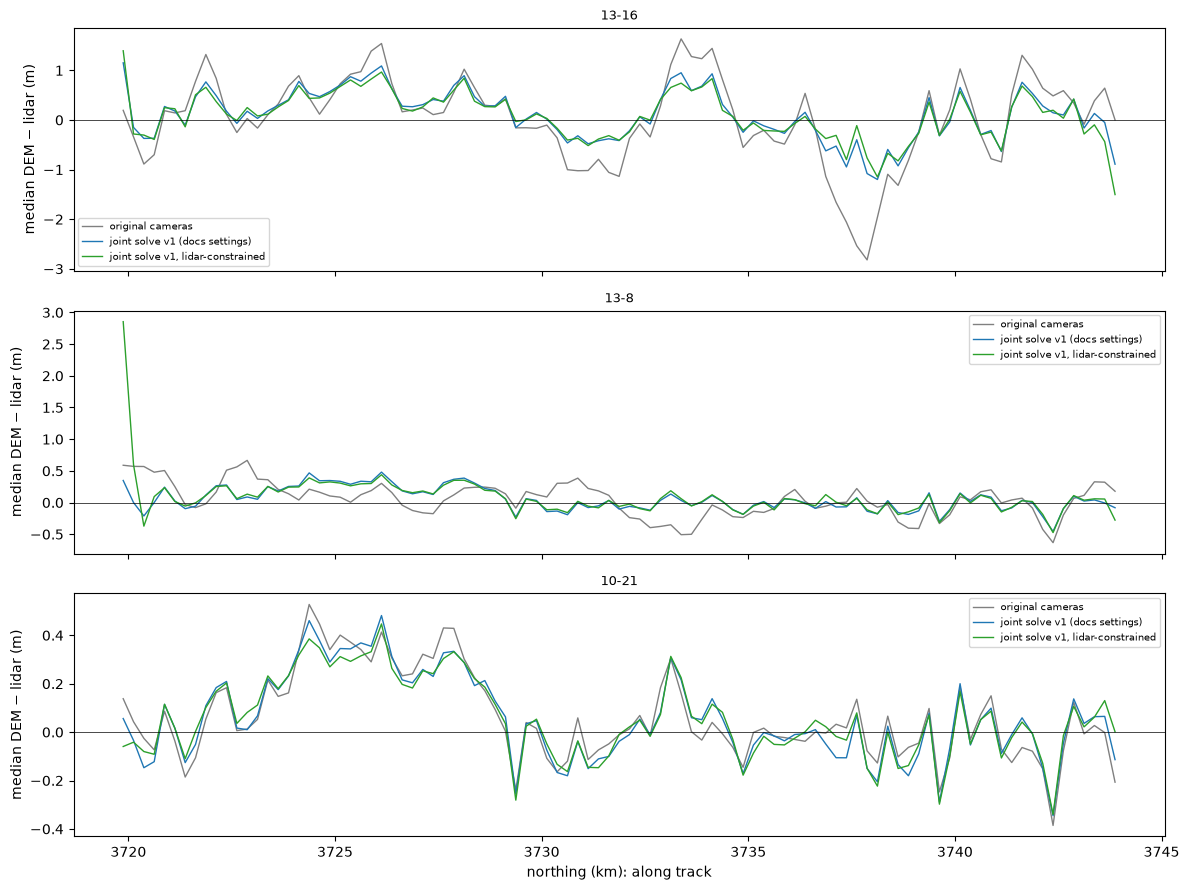

In [7]:
alj = pd.read_csv(f"{LID}/compare_jitter_tier1/along_track.csv")
fig, axs = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
for ax, name in zip(axs, ["13-16", "13-8", "10-21"]):
    for v, c in (("original", "0.5"), ("nohfd", "C0"), ("lidar", "C2")):
        g = alj[(alj.label == f"{name}_{v}") & (alj.n > 2000)]
        ax.plot(g.northing / 1e3, g["median"], c=c, lw=1, label=VARIANTS[v])
    ax.axhline(0, c="k", lw=0.5); ax.set_title(name, fontsize=9); ax.set_ylabel("median DEM − lidar (m)"); ax.legend(fontsize=7)
axs[-1].set_xlabel("northing (km): along track"); plt.tight_layout()
w = alj[alj.n > 2000].pivot(index="northing", columns="label", values="median")
rip = (w - w.rolling(9, center=True, min_periods=3).median()).std()
pd.DataFrame({v: [rip[f"{n}_{v}"] for n, *_ in TIER1] for v in ("original", "nohfd", "lidar")},
             index=[n.replace("_", " ") for n, *_ in TIER1]).round(3).rename(columns=VARIANTS)

### 7. All ten pairs and the three blends

Tier 1 passed the gate, so all ten pairs were re-triangulated with the joint (no ground constraint) cameras, in two versions:
- **v1**, the docs' WorldView-3 settings (camera position uncertainty 1000 m, 400 lines per position sample). Its camera centres moved by up to 17 km (section 2), unphysical for WorldView-2, because with nearly parallel scan lines position and attitude trade off almost freely.
- **v2**, the trajectory kept rigid as in the docs' later examples: 10,000 lines per position sample and a 10 m position uncertainty. Its camera centres move 2–5 m horizontally and 8–22 m vertically, with the same final residuals.

The pairs re-triangulated were:
- 8-10 (4.8°), 16-21 (5.4°), 8-16 (21.6°), 10-16 (26.3°) and 8-21 (27.0°);
- the benchmark's three blends were rebuilt from the corrected pairs: the 10-pair average, the 10-pair median, and the 6 pairs above 15°.

The 39 DEMs (13 original, 13 v1, 13 v2) are scored on their shared ICESat-2 points and shared open-ground lidar cells. Δ is after − before, with its paired 95 % interval.

**Do the solves misregister the pairs against each other?** One worry about a blend of corrected pairs is that the solve might shift the scenes slightly against each other. Each pair is re-aligned to ICESat-2 on its own, but a blend averages pairs before any alignment. The ICESat-2 alignment shifts of the ten pairs do scatter more after the solve. But a horizontal shift fitted to sparse points over flat ground is poorly determined, so this is checked densely instead: each pair DEM is aligned to 13-8 from the same camera set with `pc_align` on millions of points (`jobs/pair_registration.sh`).

In [8]:
import re as _re
rows = []
for d in sorted(glob.glob(f"{J}/registration/*/")):
    v, p = os.path.basename(d.rstrip("/")).split("_", 1)
    log = open(glob.glob(f"{d}run-log-pc_align*.txt")[0]).read()
    n, e, dn = map(float, _re.findall(r"Translation vector \(North-East-Down, meters\): Vector3\(([^)]*)\)", log)[-1].split(","))
    med = float(_re.findall(r"Output: mean of smallest errors \(meters\): 25%: [0-9.]+, 50%: ([0-9.]+)", log)[-1])
    rows.append({"pair vs 13-8": p.replace("_", "-"), "cameras": "original" if v == "original" else "v2",
                 "north (m)": n, "east (m)": e, "down (m)": dn, "mean of smallest 50 % of errors (m)": med})
reg = pd.DataFrame(rows).pivot(index="pair vs 13-8", columns="cameras")
reg.round(2)

north (m)       east (m)       down (m)        \
cameras       original    v2 original    v2 original    v2   
pair vs 13-8                                                 
10-16            -0.44 -0.47     0.07  0.08    -0.39 -0.13   
10-21            -0.45 -0.74     0.17  0.21    -0.25 -0.09   
13-16             1.53  1.50    -0.13 -0.05    -0.56 -0.16   
16-21             0.59  0.72     0.01  0.09     0.80  0.52   
8-16             -0.33 -0.31     0.07  0.07    -0.26 -0.16   
8-21             -0.36 -0.36     0.18  0.22    -0.11 -0.10   

             mean of smallest 50 % of errors (m)        
cameras                                 original    v2  
pair vs 13-8                                            
10-16                                       0.19  0.16  
10-21                                       0.22  0.18  
13-16                                       0.50  0.40  
16-21                                       0.48  0.32  
8-16                                        0.15  0.14  
8-21                                        0.20  0.16

The horizontal offsets between pairs are the same before and after the solve; for example, 13-16 sits about 1.5 m north of 13-8 either way, an offset already there after bundle adjustment. The vertical offsets between pairs shrink, and so does the residual disagreement once they are aligned (the mean of the smallest half of the point errors). **The corrected pairs agree with each other better, not worse.** The extra scatter in the ICESat-2 alignment shifts is noise in fitting horizontal shifts to sparse points over flat ground.

In [9]:
CONV = {"13-16": 4.5, "8-10": 4.8, "16-21": 5.4, "13-21": 9.9, "13-8": 17.0, "8-16": 21.6, "13-10": 21.8,
        "10-16": 26.3, "8-21": 27.0, "10-21": 31.7}
BLENDS = {"10_pairs_mosaic": "10-pair average", "10_pairs_median_mosaic": "10-pair median",
          "6_pairs_15_mosaic": "6 pairs > 15°"}
allb = pd.read_csv(f"{J}/bench_all_v2/dem_benchmark.csv").set_index("label")
alll = pd.read_csv(f"{LID}/compare_jitter_all_v2/stats.csv").set_index("label")
latA = np.load(f"{LID}/compare_jitter_all_v2/lattice.npz")
benchA = DEMBenchmark(f"{J}/bench_all_v2",
                      {l: allb.loc[l, "dem_fn"] for l in allb.index}, parquet=f"{FB}/atl06sr_all.parquet",
                      filter_out=["water", "trees"], n_bootstrap=0)
with contextlib.redirect_stdout(io.StringIO()):
    benchA.run(pc_align=True)
labsA = list(allb.index)
isA = np.vstack([benchA.dh_aligned[l].reindex(benchA.shared_ids).values for l in labsA])
bsA_is2 = paired_block_bootstrap(isA, blocks=pd.Series(benchA.blocks).reindex(benchA.shared_ids).values, n_boot=1000)
li = {l: i for i, l in enumerate(latA["labels"])}
lidA = np.vstack([latA["dh"][li[l]] for l in labsA])
bsA_lid = paired_block_bootstrap(lidA, blocks=latA["blocks"], n_boot=1000)
print(f"{len(benchA.shared_ids):,} shared ICESat-2 points; {lidA.shape[1]:,} lidar lattice cells")

rows = []
for base in list(CONV) + list(BLENDS):
    r = {"DEM": BLENDS.get(base, base), "conv (°)": CONV.get(base, np.nan)}
    for ref, M, bs in (("ICESat-2", isA, bsA_is2), ("lidar", lidA, bsA_lid)):
        i0 = labsA.index(f"{base}_original")
        r[f"{ref} before"] = nmad(M[i0])
        for v, tag in (("nohfd", "v1"), ("v2", "v2")):
            i1 = labsA.index(f"{base}_{v}")
            d = bs["nmad"][:, i1] - bs["nmad"][:, i0]
            lo, hi = np.percentile(d, [2.5, 97.5])
            r[f"{ref} Δ {tag} [95 %]"] = f"{nmad(M[i1]) - nmad(M[i0]):+.3f} [{lo:+.3f}, {hi:+.3f}]"
    rows.append(r)
full = pd.DataFrame(rows).set_index("DEM")
full.round(3)

40,325 shared ICESat-2 points; 92,875 lidar lattice cells


,conv (°),ICESat-2 before,ICESat-2 Δ v1 [95 %],ICESat-2 Δ v2 [95 %],lidar before,lidar Δ v1 [95 %],lidar Δ v2 [95 %]
DEM,,,,,,,
13-16,4.5,1.642,"-0.187 [-0.210, -0.167]","-0.187 [-0.211, -0.165]",1.557,"-0.185 [-0.224, -0.150]","-0.184 [-0.223, -0.148]"
8-10,4.8,1.510,"-0.129 [-0.157, -0.109]","-0.125 [-0.149, -0.104]",1.433,"-0.118 [-0.154, -0.081]","-0.111 [-0.149, -0.072]"
16-21,5.4,1.577,"-0.350 [-0.375, -0.323]","-0.345 [-0.367, -0.319]",1.484,"-0.348 [-0.387, -0.305]","-0.335 [-0.375, -0.292]"
13-21,9.9,1.235,"-0.141 [-0.161, -0.124]","-0.143 [-0.162, -0.125]",1.128,"-0.160 [-0.186, -0.130]","-0.161 [-0.187, -0.131]"
13-8,17.0,0.993,"-0.031 [-0.043, -0.020]","-0.026 [-0.037, -0.014]",0.852,"-0.043 [-0.066, -0.023]","-0.038 [-0.060, -0.017]"
8-16,21.6,0.955,"+0.000 [-0.009, +0.012]","+0.008 [-0.001, +0.021]",0.799,"+0.004 [-0.011, +0.016]","+0.017 [+0.004, +0.030]"
13-10,21.8,0.930,"-0.007 [-0.016, +0.003]","+0.000 [-0.009, +0.010]",0.776,"+0.001 [-0.012, +0.015]","+0.009 [-0.004, +0.022]"
10-16,26.3,0.924,"+0.006 [-0.003, +0.015]","+0.012 [+0.000, +0.021]",0.774,"+0.005 [-0.006, +0.016]","+0.005 [-0.007, +0.015]"
8-21,27.0,0.950,"-0.015 [-0.025, -0.007]","-0.016 [-0.025, -0.006]",0.803,"-0.017 [-0.026, -0.008]","-0.017 [-0.028, -0.007]"


best best NMAD (m)  \
ICESat-2 original cameras                  6 pairs > 15°       0.90421   
         joint solve v1 (docs settings)    6 pairs > 15°      0.913601   
         joint solve v2 (rigid positions)  6 pairs > 15°      0.909149   
lidar    original cameras                  6 pairs > 15°      0.760507   
         joint solve v1 (docs settings)    6 pairs > 15°      0.775053   
         joint solve v2 (rigid positions)  6 pairs > 15°      0.769262   

                                          best − worst (m)  \
ICESat-2 original cameras                         0.738016   
         joint solve v1 (docs settings)           0.541723   
         joint solve v2 (rigid positions)         0.546006   
lidar    original cameras                         0.796341   
         joint solve v1 (docs settings)           0.596651   
         joint solve v2 (rigid positions)         0.603618   

                                          spread, pairs > 15° and blends (m)  \
ICESat-2 original cameras                                            0.22289   
         joint solve v1 (docs settings)                             0.134097   
         joint solve v2 (rigid positions)                            0.13911   
lidar    original cameras                                           0.263509   
         joint solve v1 (docs settings)                             0.160757   
         joint solve v2 (rigid positions)                           0.170077   

                                          separable from the best (of 12)  
ICESat-2 original cameras                                              12  
         joint solve v1 (docs settings)                                11  
         joint solve v2 (rigid positions)                              12  
lidar    original cameras                                              12  
         joint solve v1 (docs settings)                                10  
         joint solve v2 (rigid positions)                              12

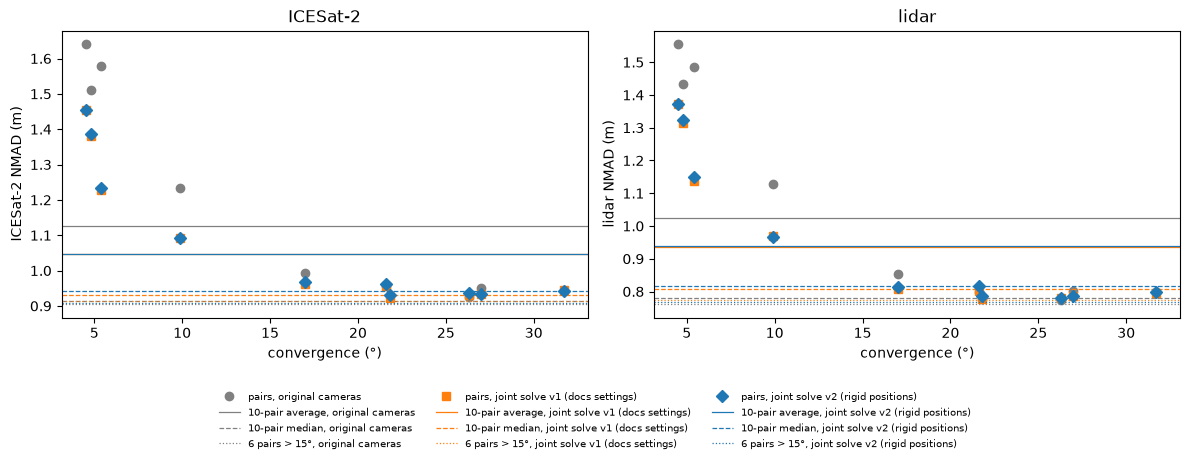

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4.6))
for ax, ref, M in ((axs[0], "ICESat-2", isA), (axs[1], "lidar", lidA)):
    for v, mk, c in (("original", "o", "0.5"), ("nohfd", "s", "C1"), ("v2", "D", "C0")):
        xs = list(CONV.values()); ys = [nmad(M[labsA.index(f"{b}_{v}")]) for b in CONV]
        ax.plot(xs, ys, mk, c=c, label="pairs, " + VARIANTS[v])
        for b, ls in zip(BLENDS, ("-", "--", ":")):
            ax.axhline(nmad(M[labsA.index(f"{b}_{v}")]), c=c, ls=ls, lw=0.9,
                       label=f"{BLENDS[b]}, {VARIANTS[v]}" if ref == "ICESat-2" else None)
    ax.set_xlabel("convergence (°)"); ax.set_ylabel(f"{ref} NMAD (m)"); ax.set_title(ref)
plt.tight_layout(rect=(0, 0.17, 1, 1))
fig.legend(*axs[0].get_legend_handles_labels(), loc="lower center", ncol=3, fontsize=7.5, frameon=False)

def ranking(M, bs, v):
    idx = [labsA.index(f"{b}_{v}") for b in list(CONV) + list(BLENDS)]
    vals = np.array([nmad(M[i]) for i in idx]); best = int(np.argmin(vals))
    d = bs["nmad"][:, idx] - bs["nmad"][:, [idx[best]]]
    sep = sum(np.percentile(d[:, k], 2.5) > 0 for k in range(len(idx)) if k != best)
    names = list(CONV) + [BLENDS[b] for b in BLENDS]
    wide = [vals[k] for k, b in enumerate(list(CONV) + list(BLENDS)) if CONV.get(b, 99) > 15]
    return {"best": names[best], "best NMAD (m)": vals[best], "best − worst (m)": vals.max() - vals.min(),
            "spread, pairs > 15° and blends (m)": max(wide) - min(wide),
            "separable from the best (of 12)": int(sep)}
pd.DataFrame({(ref, VARIANTS[v]): ranking(M, bs, v) for ref, M, bs in (("ICESat-2", isA, bsA_is2), ("lidar", lidA, bsA_lid))
              for v in ("original", "nohfd", "v2")}).T

### Key takeaways

1. **The Atlanta WorldView-2 strips have measurable attitude jitter, and the narrow pairs pay for it.**
    - The triangulation error carries a quasi-periodic along-track wave with a period of 2–3 km, out of phase between pairs.
    - Against lidar, the short-scale along-track ripple of the DEMs is about 0.1 m for pairs above 20°, 0.15 m at 17° and 0.44–0.50 m at 4.5–5.4°. That is the 1/(base-to-height) amplification of an angular error.
2. **Only a joint solve over all five scenes helps.**
    - Solving one pair at a time removes the jitter from the reprojection residuals but leaves the DEM unchanged (13-8: +0.004 m): a pair cannot see the part of the jitter that turns into height.
    - The docs' COP30 height constraint (10 m) makes things much worse in wooded Atlanta (13-8: 1.05 → 1.91 m), because COP30 sits on the canopy.
3. **The joint solve corrects the narrow pairs and leaves the wide ones alone.** On ICESat-2, with paired 95 % intervals; the lidar agrees:
    - 4.5–9.9° pairs improve by 0.13–0.35 m (16-21: 1.58 → 1.23 m; 13-16: 1.64 → 1.46 m), and their ripple falls (13-16: 0.45 → 0.30 m).
    - 13-8 (17°) improves by 0.03 m.
    - The pairs above 20° change by less than ±0.02 m, mostly not separable from zero.
4. **On the separability question: correcting jitter makes the DEMs less different, but does not change which are best.**
    - The best − worst gap shrinks by about a quarter (0.74 → 0.55 m on ICESat-2, 0.80 → 0.60 m on lidar), almost entirely because the narrow pairs and the plain 10-pair average (1.13 → 1.05 m) get better.
    - The best DEM is still the 6-pair >15° blend (0.90–0.91 m). With the rigid-position solve (v2), all twelve other DEMs stay separable from it, as before; with v1, 10–11 do.
    - The benchmark's rules hold: use pairs above ~15°, and blend them with the narrow pairs dropped or with `--median`. Including narrow pairs now costs less (0.14 m for the plain average, down from 0.22 m).
5. **The blends that were already good do not improve.** The >15° blend is unchanged (+0.005 to +0.015 m). The 10-pair median blend gets slightly worse (+0.015 to +0.035 m, separable from zero).
    - It is not misregistration: aligned densely, the corrected pairs agree with each other *better* than before (section 7).
    - The likely reason is that the median already rejected most of the narrow pairs' jitter, so the correction has little left to give it. Why it loses a little is open.
6. **Settings.**
    - The docs' WorldView-3 example uses a 1000 m camera position uncertainty and samples positions as finely as orientations. Here that moves the camera centres by up to 17 km, unphysical, because with same-pass, nearly parallel scan lines position and attitude trade off.
    - Keeping the positions rigid (10,000 lines per position sample, 10 m uncertainty) gives physical cameras (2–5 m horizontal moves) and the same DEMs within ±0.01 m. Use the rigid form.
    - A lidar height constraint on open ground adds a further 0.01–0.02 m on the wide pairs (ICESat-2-checked) but is not needed.
7. **Cost.** Re-triangulating from archived disparity (`--prev-run-prefix`) costs about 1.5 node-hours per pair against about 18 for new stereo, and the solves take 20–30 minutes on one node. The whole experiment (six solves, 34 re-triangulations, the scoring) used about 65 SBU on the NASA NAS supercomputer.

**Scope and follow-ups.**
- One same-pass WorldView-2 stack over mostly flat ground.
- A multi-date stack with crossing scan lines, such as UCSD, is the better-posed case for `jitter_solve`; there the scenes' jitter would also stop being shared by every pair of the stack.
- The multi-view runs were not re-triangulated.